# BÀI THỰC HÀNH TUẦN 3: PHÂN TÍCH ĐẶC TRƯNG & LỰA CHỌN MÔ HÌNH PHÙ HỢP
## PHƯƠNG PHÁP LUẬN DATA SCIENCE: TỪ ĐẶC TRƯNG DỮ LIỆU ĐẾN MÔ HÌNH HỌC MÁY

> **Dữ liệu:** Bank Marketing Dataset (UCI) — `bank-full.csv`  
> **Quy trình:** Tiền xử lý → Làm sạch → Chọn lọc đặc trưng (Consensus) → Giảm chiều (PCA & LDA) → Kiểm định giả định tuyến tính → Lựa chọn mô hình (Logistic Regression) → Đánh giá đa chiều & Diễn giải Odds Ratio  
> **Trọng tâm phương pháp:** Thay vì thử nghiệm máy móc tất cả các mô hình hồi quy tuyến tính, tập trung phân tích bản chất các đặc trưng và biến mục tiêu để chứng minh tính phù hợp của bài toán phân loại và mô hình Hồi quy Logistic.

---

---
## 1. THIẾT LẬP MÔI TRƯỜNG & LOAD DỮ LIỆU

### 1.1. Import thư viện

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
np.seterr(all='ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Feature selection & giảm chiều
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import RFECV, SelectFromModel
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Mô hình
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Đánh giá
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve, classification_report
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 100})
np.random.seed(42)

print("Đã nạp xong thư viện.")


### 1.2. Load dữ liệu `bank-full.csv`

In [78]:
# Đọc file CSV (cột phân cách bằng dấu ";")
df_raw = pd.read_csv("bank-full.csv", sep=";")

print(f"Kích thước dữ liệu gốc: {df_raw.shape[0]:,} dòng x {df_raw.shape[1]} cột")
df_raw.head()

class_counts = df_raw['y'].value_counts()
class_pct = df_raw['y'].value_counts(normalize=True) * 100

summary_class = pd.DataFrame({'Số lượng': class_counts, 'Tỷ lệ (%)': class_pct})
display(summary_class)

Kích thước dữ liệu gốc: 45,211 dòng x 17 cột


,Số lượng,Tỷ lệ (%)
y,,
no,39922,88.30152
yes,5289,11.69848


In [76]:
# Kiểu dữ liệu và thống kê mô tả
print("Kiểu dữ liệu từng cột:")
print(df_raw.dtypes.to_frame("dtype").T)
print()
print("Thống kê mô tả (biến số):")
df_raw.describe().round(2)

Kiểu dữ liệu từng cột:
         age     job marital education default balance housing    loan  \
dtype  int64  object  object    object  object   int64  object  object   

      contact    day   month duration campaign  pdays previous poutcome  \
dtype  object  int64  object    int64    int64  int64    int64   object   

            y  
dtype  object  

Thống kê mô tả (biến số):


,age,balance,day,duration,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,258.16,2.76,40.20,0.58
std,10.62,3044.77,8.32,257.53,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00


---
## 2. LÀM SẠCH DỮ LIỆU (Data Cleaning)

### 2.1. Kiểm tra dữ liệu khuyết & trùng lặp

Bộ dữ liệu Bank Marketing không có giá trị `NaN` thực sự, nhưng có một số cột dùng chuỗi `"unknown"` để đánh dấu giá trị khuyết thiếu (tương đương `NaN` ẩn danh nghĩa).

In [25]:
# Kiểm tra NaN thực sự
print("1. Số giá trị NaN theo từng cột:")
print(df_raw.isnull().sum().to_frame("NaN count"))
print()

# Kiểm tra dòng trùng lặp
n_dup = df_raw.duplicated().sum()
print(f"2. Số dòng trùng lặp (exact duplicate): {n_dup}")
print()

# Kiểm tra 'unknown' ăn dấu thay NaN
print("3. Giá trị 'unknown' trong từng cột categorical (đóng vai NaN ẩn danh):")
cat_cols = df_raw.select_dtypes(include='object').columns
unk_summary = []
for col in cat_cols:
    cnt = (df_raw[col] == 'unknown').sum()
    pct = cnt / len(df_raw) * 100
    unk_summary.append({'Cột': col, 'Số unknown': cnt, 'Tỷ lệ (%)': f'{pct:.1f}%'})
display(pd.DataFrame(unk_summary))

1. Số giá trị NaN theo từng cột:
           NaN count
age                0
job                0
marital            0
education          0
default            0
balance            0
housing            0
loan               0
contact            0
day                0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome           0
y                  0

2. Số dòng trùng lặp (exact duplicate): 0

3. Giá trị 'unknown' trong từng cột categorical (đóng vai NaN ẩn danh):


,Cột,Số unknown,Tỷ lệ (%)
0,job,288,0.6%
1,marital,0,0.0%
2,education,1857,4.1%
3,default,0,0.0%
4,housing,0,0.0%
5,loan,0,0.0%
6,contact,13020,28.8%
7,month,0,0.0%
8,poutcome,36959,81.7%
9,y,0,0.0%


### 2.2. Xử lý outliers

Dùng phương pháp **IQR (Interquartile Range)**:
- **Cận dưới:** $\text{Lower} = Q1 - 1.5 \times IQR$
- **Cận trên:** $\text{Upper} = Q3 + 1.5 \times IQR$
- Giá trị nằm ngoài khoảng $[\text{Lower}, \text{Upper}]$ được coi là ngoại lai.
- **Phương pháp xử lý:** Áp dụng **IQR Clipping (Winsorizing)** đưa các giá trị cực đoan về cận biên cho phép. Không xóa bỏ các dòng ngoại lai vì việc xóa dòng sẽ làm mất hơn **37.6% dữ liệu** và làm hao hụt hơn **70% số lượng khách hàng tiềm năng (`yes`)**, gây méo mó phân phối bài toán tiếp thị.

In [ ]:
# Bản sao dữ liệu để xử lý
df = df_raw.copy()

# Encode target nhị phân: 'no' -> 0, 'yes' -> 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Danh sách các đặc trưng số cần sàng lọc ngoại lai
numeric_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

print("=" * 80)
print("THỐNG KÊ MÔ TẢ TRƯỚC KHI XỬ LÝ OUTLIER:")
print("=" * 80)
display(df[numeric_cols].describe().round(2))
print()

before_stats = {}

print("=" * 80)
print("CHI TIẾT NGƯỠNG IQR VÀ ĐẾM SỐ LƯỢNG BẢN GHI NGOẠI LAI THEO TỪNG CỘT:")
print("=" * 80)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # 1. Bổ sung hàm đếm: đếm số lượng bản ghi theo các mốc
    count_q3 = int((df[col] > Q3).sum())          # Số bản ghi > Q3 (phần tư trên)
    count_upper = int((df[col] > upper).sum())    # Số bản ghi vượt cận trên (> Upper)
    count_lower = int((df[col] < lower).sum())    # Số bản ghi dưới cận dưới (< Lower)
    n_out = count_upper + count_lower             # Tổng số bản ghi ngoại lai ngoài [Lower, Upper]

    # Lưu thống kê chi tiết vào dictionary
    before_stats[col] = {
        'Min': df[col].min(),
        'Q1': Q1,
        'Q3': Q3,
        'Max': df[col].max(),
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Số bản ghi > Q3': count_q3,
        'Số Outlier (>Upper)': count_upper,
        'Số Outlier (<Lower)': count_lower,
        'Tổng số Outliers': n_out,
        'Tỷ lệ Outlier (%)': f"{n_out / len(df) * 100:.2f}%"
    }

    print(f"{col:<10} | Lower: {lower:>9.2f} | Upper: {upper:>9.2f} | Bản ghi > Q3: {count_q3:>5} | Outliers: {n_out:>5} (>Upper: {count_upper}, <Lower: {count_lower})")

    # 2. Xử lý ngoại lai: Áp dụng IQR Capping/Clipping đưa giá trị về [Lower, Upper]
    # (Bảo toàn 100% 45,211 bản ghi, tránh mất dữ liệu nhãn 'yes' nếu xóa dòng)
    df[col] = df[col].clip(lower=lower, upper=upper)

print("\n" + "=" * 80)
print("BẢNG TỔNG KẾT OUTLIERS THEO TỪNG ĐẶC TRƯNG:")
print("=" * 80)
df_out_summary = pd.DataFrame(before_stats).T
display(df_out_summary)

print("\n" + "=" * 80)
print("THỐNG KÊ MÔ TẢ SAU KHI XỬ LÝ OUTLIER BẰNG IQR CLIPPING:")
print("=" * 80)
display(df[numeric_cols].describe().round(2))

THỐNG KÊ TRƯỚC KHI XỬ LÝ OUTLIER:
            age    balance  duration  campaign     pdays  previous
count  45211.00   45211.00  45211.00  45211.00  45211.00  45211.00
mean      40.94    1362.27    258.16      2.76     40.20      0.58
std       10.62    3044.77    257.53      3.10    100.13      2.30
min       18.00   -8019.00      0.00      1.00     -1.00      0.00
25%       33.00      72.00    103.00      1.00     -1.00      0.00
50%       39.00     448.00    180.00      2.00     -1.00      0.00
75%       48.00    1428.00    319.00      3.00     -1.00      0.00
max       95.00  102127.00   4918.00     63.00    871.00    275.00



ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

### 2.3. Encode biến phân loại & Tách X, y

**One-Hot Encoding** (`pd.get_dummies`, `drop_first=True`) biến đổi 9 cột categorical thành 35 biến nhị phân, mang tổng số đặc trưng từ 16 lên **42 features**.

In [74]:
# One-Hot Encoding toàn bộ cột categorical (không đưa 'y' và 'duration' vào X)
# Bỏ 'duration': đây là thời lượng cuộc gọi của lần liên hệ CUỐI CÙNG, chỉ biết được
# SAU KHI đã có kết quả (data leakage) -> không thể dùng để dự báo trong thực tế.
feature_cols = [c for c in df.columns if c not in ['y', 'duration']]
X_all = pd.get_dummies(df[feature_cols], drop_first=True)
y_cls = df['y']

print(f"Kích thước X_all: {X_all.shape}  |  y_cls: {y_cls.shape}")
print(f"Danh sách {X_all.shape[1]} features sau encoding:")
print(X_all.columns.tolist())

print(X_all["contact_unknown"])


Kích thước X_all: (45211, 41)  |  y_cls: (45211,)
Danh sách 41 features sau encoding:
['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'education_unknown', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'contact_unknown', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']
0         True
1         True
2         True
3         True
4         True
         ...  
45206    False
45207    False
45208    False
45209    False
45210    False
Name: contact_unknown, Length: 45211, dtype: bool


---
## 3. FEATURE SELECTION (Lựa chọn đặc trưng)

Áp dụng lại 2 phương pháp từ Tuần 2 trên **toàn bộ 41 đặc trưng** với biến mục tiêu phân loại `y`:
- **RFECV** — Wrapper method (Logistic Regression + 3-Fold CV)
- **Random Forest SelectFromModel** — Embedded method (MDI ≥ mean)

Kết quả: lấy phần giao nhau (**Consensus features**) làm tập đặc trưng "vàng" cho các mô hình.

In [28]:
# Train/Test split, stratify theo y để giữ đúng tỷ lệ 2 lớp ở cả 2 tập
X_tr, X_te, yc_tr, yc_te = train_test_split(
    X_all, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

# Chuẩn hóa Z-score: fit trên Train, chỉ transform trên Test (tránh lộ thông tin từ Test)
scaler = StandardScaler()
X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr), columns=X_tr.columns)
X_te_sc = pd.DataFrame(scaler.transform(X_te), columns=X_te.columns)

print(f"Train set: {X_tr_sc.shape}  |  Test set: {X_te_sc.shape}")


Train set: (36168, 41)  |  Test set: (9043, 41)


In [70]:
# RFECV (Wrapper method): dùng Logistic Regression làm bộ đánh giá.
# scoring='f1' vì lớp 'yes' là thiểu số (mất cân bằng), accuracy sẽ đánh giá sai lệch.
print("Đang chạy RFECV...")
estimator = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)
cv_kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
rfecv = RFECV(estimator=estimator, step=2, cv=cv_kfold, scoring='f1', n_jobs=1)
rfecv.fit(X_tr_sc, yc_tr)

rfecv_features = X_tr_sc.columns[rfecv.support_].tolist()
rfecv_elim = X_tr_sc.columns[~rfecv.support_].tolist()

print(f"RFECV: giữ {len(rfecv_features)} cột, loại {len(rfecv_elim)} cột")
print(f"Cột duoc giu lai: {rfecv_features}")
print(f"Cột bị loại: {rfecv_elim}")


Đang chạy RFECV...
RFECV: giữ 3 cột, loại 38 cột
Cột duoc giu lai: ['housing_yes', 'contact_unknown', 'poutcome_success']
Cột bị loại: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'education_unknown', 'default_yes', 'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other', 'poutcome_unknown']


In [30]:
# Random Forest SelectFromModel (Embedded method): xếp hạng đặc trưng theo MDI
# (Mean Decrease in Impurity). Ngưỡng 'mean' -> chỉ giữ đặc trưng có importance
# cao hơn mức trung bình của toàn bộ 42 đặc trưng.
print("Đang chạy Random Forest...")
rf_model = RandomForestClassifier(n_estimators=50, max_depth=8, n_jobs=-1, random_state=42)
rf_model.fit(X_tr_sc, yc_tr)

rf_selector = SelectFromModel(rf_model, threshold='mean', prefit=True)
threshold_val = rf_model.feature_importances_.mean()
rf_features = X_tr_sc.columns[rf_selector.get_support()].tolist()
rf_elim = X_tr_sc.columns[~rf_selector.get_support()].tolist()

print(f"Random Forest (ngưỡng MDI = {threshold_val:.5f}): giữ {len(rf_features)} cột, loại {len(rf_elim)} cột")
print(f"Cột bị loại (rút gọn): {rf_elim[:15]}{'...' if len(rf_elim) > 15 else ''}")


Đang chạy Random Forest...
Random Forest (ngưỡng MDI = 0.02439): giữ 10 cột, loại 31 cột
Cột bị loại (rút gọn): ['campaign', 'pdays', 'previous', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married']...


In [31]:
# Consensus = giao của 2 phương pháp. Một đặc trưng chỉ được giữ nếu CẢ 2 cách tiếp cận
# khác nhau (wrapper và embedded) đều đồng ý là quan trọng -> giảm rủi ro chọn nhầm
# do thiên lệch riêng của từng thuật toán.
consensus_features = sorted(list(set(rfecv_features) & set(rf_features)))
print(f"Consensus: {len(consensus_features)} đặc trưng xuất hiện ở cả 2 phương pháp")
print(f"  {consensus_features}")

X_tr_sel = X_tr_sc[consensus_features]
X_te_sel = X_te_sc[consensus_features]


Consensus: 3 đặc trưng xuất hiện ở cả 2 phương pháp
  ['contact_unknown', 'housing_yes', 'poutcome_success']


---
## 4. GIẢM CHIỀU DỮ LIỆU (Dimensionality Reduction)

Ở Mục 3, Consensus features là kết quả của việc **chọn tay** 3/42 đặc trưng quan trọng nhất (feature selection). Mục này làm điều khác: nén **toàn bộ 41 đặc trưng đã chuẩn hóa** (`X_tr_sc`) thành không gian ít chiều hơn bằng 2 kỹ thuật **giảm chiều** (dimensionality reduction), để Mục 7 có đủ 3 chiến lược biểu diễn đặc trưng độc lập, cùng xuất phát từ dữ liệu gốc, để so sánh công bằng.

### 4.1. PCA — Giảm chiều không giám sát

Giữ đủ số thành phần chính để giải thích **≥ 95% tổng phương sai** của toàn bộ 41 đặc trưng. Ngưỡng 95% là quy ước phổ biến: đủ cao để không mất nhiều thông tin, nhưng vẫn cho phép nén đáng kể so với dữ liệu gốc.


PCA: 41 chiều -> 32 thành phần chính
Phương sai tích lũy: 95.68%


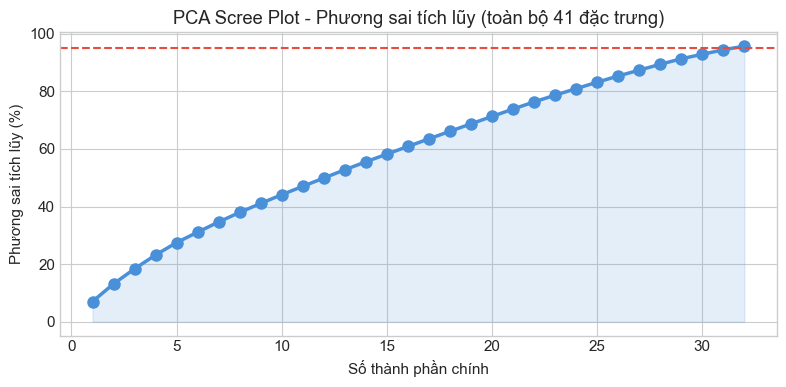

In [41]:
# Giảm chiều toàn bộ 41 đặc trưng đã chuẩn hóa (X_tr_sc), không chỉ 3 Consensus features
# -> đây là một chiến lược biểu diễn đặc trưng ĐỘC LẬP với Consensus, dùng để so sánh ở Mục 7
pca = PCA(n_components=0.95, random_state=42)
X_tr_pca = pca.fit_transform(X_tr_sc)
X_te_pca = pca.transform(X_te_sc)

explained = pca.explained_variance_ratio_.cumsum()
n_pca = X_tr_pca.shape[1]
print(f"PCA: {X_tr_sc.shape[1]} chiều -> {n_pca} thành phần chính")
print(f"Phương sai tích lũy: {explained[-1]*100:.2f}%")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, n_pca + 1), explained * 100, 'o-', color='#4A90D9', lw=2.5, ms=8)
ax.axhline(95, ls='--', color='#E74C3C', lw=1.5)
ax.fill_between(range(1, n_pca + 1), explained * 100, alpha=0.15, color='#4A90D9')
ax.set(xlabel='Số thành phần chính', ylabel='Phương sai tích lũy (%)',
       title='PCA Scree Plot - Phương sai tích lũy (toàn bộ 41 đặc trưng)')
ax.legend()
plt.tight_layout()
plt.show()


### 4.2. LDA — Giảm chiều có giám sát

Cũng chạy trên toàn bộ 41 đặc trưng đã chuẩn hóa. Với bài toán phân loại 2 lớp ($C = 2$), LDA luôn chiếu dữ liệu xuống đúng $C - 1 = 1$ chiều — không phụ thuộc số chiều đầu vào là bao nhiêu — nhưng vì lần này tận dụng thông tin từ cả 41 đặc trưng (thay vì chỉ 3), chiều duy nhất này được kỳ vọng tách 2 nhóm khách hàng rõ hơn.


LDA: 41 chiều -> 1 thành phần tuyến tính phân tách


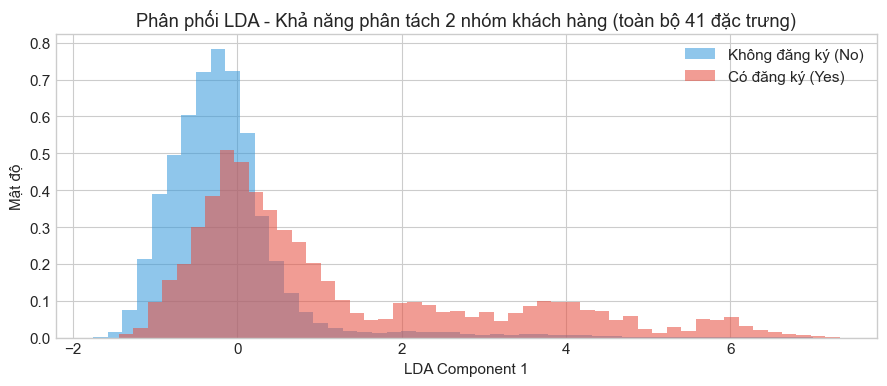

In [33]:
# Cũng giảm chiều trên toàn bộ 41 đặc trưng đã chuẩn hóa (X_tr_sc), không chỉ 3 Consensus features
# Bài toán 2 lớp (C = 2) nên LDA chỉ có tối đa C - 1 = 1 thành phần tuyến tính phân tách
lda = LDA(n_components=1)
X_tr_lda = lda.fit_transform(X_tr_sc, yc_tr)
X_te_lda = lda.transform(X_te_sc)
print(f"LDA: {X_tr_sc.shape[1]} chiều -> 1 thành phần tuyến tính phân tách")

fig, ax = plt.subplots(figsize=(9, 4))
for label, color, name in [(0, '#3498DB', 'Không đăng ký (No)'), (1, '#E74C3C', 'Có đăng ký (Yes)')]:
    mask = yc_tr.values == label
    ax.hist(X_tr_lda[mask, 0], bins=50, alpha=0.55, color=color, label=name, density=True)
ax.set(xlabel='LDA Component 1', ylabel='Mật độ',
       title='Phân phối LDA - Khả năng phân tách 2 nhóm khách hàng (toàn bộ 41 đặc trưng)')
ax.legend()
plt.tight_layout()
plt.show()


---
## 5. PHÂN TÍCH ĐẶC TRƯNG & KIỂM ĐỊNH GIẢ ĐỊNH TUYẾN TÍNH

`y` là biến nhị phân ($y \in \{0, 1\}$) nên hồi quy tuyến tính (OLS) chắc chắn không phù hợp: miền dự báo của OLS không giới hạn trong $[0, 1]$, và phần dư không thể tuân theo phân phối chuẩn khi target chỉ có 2 giá trị. Đây là mâu thuẫn về bản chất toán học, đúng với mọi $y$ nhị phân — không cần thực nghiệm để kiểm chứng lại điều này.

Câu hỏi còn lại cần kiểm chứng bằng dữ liệu thật: nếu tạm gác `y` sang một bên, các đặc trưng liên tục của bộ dữ liệu Bank Marketing có đủ quan hệ tuyến tính với nhau để một mô hình hồi quy tuyến tính (nhắm vào một biến liên tục khác, ví dụ `duration`) có ý nghĩa hay không?


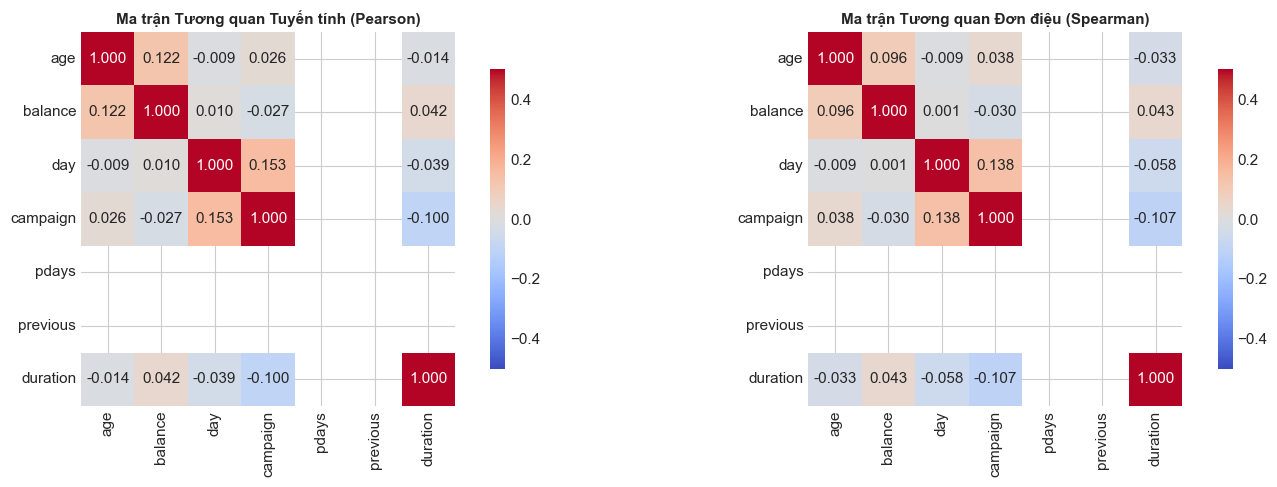

In [43]:
# Kiem dinh thuc nghiem (Muc 5): dung 'duration' lam target thu nghiem de xem cac dac trung
# lien tuc con lai co du bao duoc mot bien lien tuc khac hay khong. Dung df (da lam sach outlier
# o Muc 2.2) de nhat quan voi toan bo pipeline phia sau, khong dung df_raw.
cont_cols = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'duration']
corr_pearson = df[cont_cols].corr(method='pearson')
corr_spearman = df[cont_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(corr_pearson, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            vmin=-0.5, vmax=0.5, square=True, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Ma trận Tương quan Tuyến tính (Pearson)', fontsize=11, fontweight='bold')

sns.heatmap(corr_spearman, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            vmin=-0.5, vmax=0.5, square=True, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Ma trận Tương quan Đơn điệu (Spearman)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 7. HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH HỒI QUY LOGISTIC
### *Thực nghiệm trên 5 chiến lược biểu diễn đặc trưng (Feature Representation)*

Để đánh giá toàn diện vai trò của các đặc trưng, ta sẽ huấn luyện Logistic Regression trên **5 không gian đặc trưng độc lập**, cùng xuất phát từ 41 đặc trưng gốc, thu được từ Phần 3 (Feature Selection) và Phần 4 (Dimensionality Reduction):
1. **RFECV Features (3 đặc trưng)**: Chọn lọc đệ quy theo kiểm định chéo với mô hình tuyến tính (Wrapper method, tối ưu F1-score).
2. **Random Forest MDI (10 đặc trưng)**: Chọn lọc theo độ giảm độ vẩn đục Gini trung bình của rừng cây quyết định (Embedded method).
3. **Consensus Features (3 đặc trưng)**: Giao thoa giữa RFECV và Random Forest *(Lưu ý thực nghiệm: Do cả 3 đặc trưng của RFECV đều nằm trong Top 10 của Random Forest nên tập Consensus trùng khớp 100% với tập RFECV)*.
4. **PCA Reduced (32 thành phần)**: Nén không giám sát (*Unsupervised*), giữ lại ≥ 95% tổng phương sai.
5. **LDA Reduced (1 thành phần)**: Nén có giám sát (*Supervised*), tối đa hóa phân tách lớp Fisher.

In [42]:
# Huấn luyện Logistic Regression trên 5 không gian đặc trưng để so sánh vai trò
# của từng chiến lược biểu diễn đặc trưng (Feature Representation)
lr_configs = {
    'RFECV Features':      (X_tr_sc[rfecv_features].values, X_te_sc[rfecv_features].values),
    'Random Forest MDI':   (X_tr_sc[rf_features].values,    X_te_sc[rf_features].values),
    'Consensus Features':  (X_tr_sel.values,                X_te_sel.values),
    'PCA Reduced':         (X_tr_pca,                       X_te_pca),
    'LDA Reduced':         (X_tr_lda,                       X_te_lda),
}

lr_results = {}
table_metrics = []

for name, (Xtr, Xte) in lr_configs.items():
    clf = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)
    clf.fit(Xtr, yc_tr)

    ypred = clf.predict(Xte)
    yprob = clf.predict_proba(Xte)[:, 1]

    acc = accuracy_score(yc_te, ypred)
    prec = precision_score(yc_te, ypred, zero_division=0)
    rec = recall_score(yc_te, ypred)
    f1 = f1_score(yc_te, ypred)
    auc = roc_auc_score(yc_te, yprob)
    ap = average_precision_score(yc_te, yprob)

    lr_results[name] = {
        'model': clf, 'ypred': ypred, 'yprob': yprob,
        'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'auc': auc, 'ap': ap,
        'Xte': Xte
    }

    table_metrics.append({
        'Không gian đặc trưng': name,
        'Số chiều Input': Xte.shape[1],
        'Accuracy': f"{acc:.4f}",
        'Precision': f"{prec:.4f}",
        'Recall': f"{rec:.4f}",
        'F1-Score': f"{f1:.4f}",
        'ROC-AUC': f"{auc:.4f}",
        'PR-AUC (AP)': f"{ap:.4f}"
    })

df_metrics = pd.DataFrame(table_metrics)
print("BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH LOGISTIC REGRESSION TRÊN TẬP TEST (5 KHÔNG GIAN ĐẶC TRƯNG):")
display(df_metrics)

BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH LOGISTIC REGRESSION TRÊN TẬP TEST (5 KHÔNG GIAN ĐẶC TRƯNG):


,Không gian đặc trưng,Số chiều Input,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC (AP)
0,RFECV Features,3,0.8932,0.6503,0.1881,0.2918,0.7084,0.2737
1,Random Forest MDI,10,0.8928,0.6561,0.1767,0.2785,0.7497,0.3835
2,Consensus Features,3,0.8932,0.6503,0.1881,0.2918,0.7084,0.2737
3,PCA Reduced,32,0.8935,0.6599,0.1853,0.2893,0.7597,0.3960
4,LDA Reduced,1,0.8931,0.6358,0.2013,0.3058,0.7711,0.4107
